# Can Perplexity Detect AI-Generated Text?

**Research Paper Assignment - Week 10**

**Authors:** Katrin Nguyen, Nico Loss

**Date:** 2025-12-16

---

## Abstract

This research investigates whether perplexity, a fundamental metric in language modeling, can effectively distinguish between AI-generated and human-written text. We collected 25 samples of each text type and computed their perplexity scores using GPT-2. Statistical analysis including t-tests, Mann-Whitney U test, Cohen's d effect size, and 95% confidence intervals were performed to compare distributions. Classification performance was evaluated using ROC curves, AUC scores, and optimal threshold determination. Error analysis identified systematic patterns in misclassifications. Our findings reveal [results will be filled after experiments] about the effectiveness of perplexity as a detection metric, with implications for content moderation, academic integrity, and understanding of language model behavior.

**Keywords:** Perplexity, AI-generated text detection, Language Models, Statistical Analysis, ROC Curve

## 1. Introduction

### 1.1 Motivation

With the widespread deployment of large language models (LLMs) such as GPT-4, Claude, and others, distinguishing between AI-generated and human-written text has become increasingly important for:

- **Academic Integrity**: Detecting potential plagiarism or unauthorized AI assistance in student submissions
- **Content Moderation**: Identifying synthetic content in journalism, social media, and online platforms
- **Misinformation Prevention**: Combating automated generation of fake news and propaganda

### 1.2 What is Perplexity?

**Perplexity** is a fundamental metric in natural language processing that measures how "surprised" a language model is when encountering a given text. Formally, it is defined as:

$$\text{Perplexity} = \exp\left(-\frac{1}{N} \sum_{i=1}^{N} \log P(\text{token}_i | \text{context})\right)$$

**Intuition:**
- **Low perplexity**: The model expected this text sequence (high probability tokens) → predictable, likely AI-generated
- **High perplexity**: The model did not expect this text (low probability tokens) → surprising, potentially human-written

**Example:**
- AI Text: "The weather is nice today." → Model: "Yes, I'd generate that!" → **Low PPL**
- Human Text: "The sky wept silver tears." → Model: "Unexpected!" → **High PPL**

### 1.3 Research Hypothesis

**Hypothesis:** AI-generated text exhibits significantly **lower perplexity** than human-written text.

**Rationale:** AI models generate text by selecting high-probability tokens, resulting in predictable sequences. Human text demonstrates more creativity, variability, and unpredictability.

### 1.4 Paper Overview

This paper is structured as follows:
- **Section 2**: Methodology including data collection, perplexity computation, and evaluation approach
- **Section 3**: Results from three experiments: distribution comparison, classification performance, and error analysis
- **Section 4**: Discussion of findings, limitations, and practical implications
- **Section 5**: Conclusions and future work directions

## 2. Methodology

### 2.1 Data Collection

We collected two balanced datasets for comparative analysis:

#### Set A: Human-Written Texts (n=25)
Sources:
- **Previous academic papers (Assignment 3 - self-written sections)** ← REQUIRED!
- Wikipedia article paragraphs on diverse topics
- News articles from reputable sources (BBC, Reuters)
- Book excerpts from Project Gutenberg

#### Set B: AI-Generated Texts (n=25)
- Generated using Claude AI and ChatGPT
- Prompts: "Write a paragraph about [topic]"
- Topics matched to human text samples for fair comparison
- **No cherry-picking**: All generated outputs were included

**Requirements:**
- Text length: 50-150 words per sample
- Topic matching across both sets
- Balanced sample sizes

### 2.2 Perplexity Computation

We use **GPT-2** (124M parameters) from Hugging Face Transformers library for perplexity calculation. GPT-2 provides access to log probabilities necessary for perplexity computation and runs efficiently on local hardware.

**Model:** `gpt2` (Hugging Face)

**Computation Method:**
1. Tokenize input text
2. Compute cross-entropy loss
3. Calculate perplexity: $PPL = \exp(\text{loss})$

### 2.3 Statistical Analysis

We employ multiple statistical methods:

1. **Descriptive Statistics**: Mean, standard deviation, min, max
2. **Confidence Intervals**: 95% CI for both group means
3. **Independent t-test**: Test for significant difference (α = 0.05)
4. **Mann-Whitney U test**: Non-parametric alternative for non-normal distributions (+2 bonus points)
5. **Cohen's d Effect Size**: Measure practical significance
   - Small: |d| = 0.2-0.5
   - Medium: |d| = 0.5-0.8
   - Large: |d| > 0.8

### 2.4 Classification Evaluation

We evaluate perplexity as a binary classifier:

- **ROC Curve**: Receiver Operating Characteristic
- **AUC**: Area Under the Curve (0.5 = random, 1.0 = perfect)
- **Optimal Threshold**: Maximize (TPR - FPR)
- **Performance Metrics**: Accuracy, Precision, Recall, F1-Score

## 3. Implementation

### 3.1 Environment Setup

In [1]:
# Import required libraries
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from sklearn.metrics import (
    roc_curve, auc, accuracy_score, 
    precision_score, recall_score, 
    f1_score, confusion_matrix,
    classification_report
)
import json
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("✅ Environment setup complete!")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'GPU' if torch.cuda.is_available() else 'CPU'}")

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Environment setup complete!
PyTorch version: 2.9.1
Device: CPU


### 3.2 Load GPT-2 Model

We load the pre-trained GPT-2 model for perplexity computation.

In [2]:
# Load GPT-2 model and tokenizer
print("Loading GPT-2 model...")
model_name = 'gpt2'
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name)

# Fix tokenizer warning: GPT-2 has no padding token by default
tokenizer.pad_token = tokenizer.eos_token
tokenizer.pad_token_id = tokenizer.eos_token_id

# Set model to evaluation mode
model.eval()

# Move to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

print(f"✅ Model loaded successfully on {device}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Loading GPT-2 model...
✅ Model loaded successfully on cpu
Model parameters: 124,439,808


### 3.3 Perplexity Calculation Function

In [3]:
def calculate_perplexity(text, model, tokenizer, max_length=512):
    """
    Calculate perplexity of a text using GPT-2.
    
    Args:
        text (str): Input text
        model: GPT-2 model
        tokenizer: GPT-2 tokenizer
        max_length (int): Maximum sequence length
    
    Returns:
        float: Perplexity score
    """
    # Tokenize input
    encodings = tokenizer(
        text, 
        return_tensors='pt', 
        truncation=True, 
        max_length=max_length
    )
    
    # Move to device
    encodings = {k: v.to(model.device) for k, v in encodings.items()}
    
    # Calculate loss (no gradient computation needed)
    with torch.no_grad():
        outputs = model(**encodings, labels=encodings['input_ids'])
        loss = outputs.loss
    
    # Perplexity = exp(loss)
    perplexity = torch.exp(loss).item()
    
    return perplexity


# Test the function
test_text = "The quick brown fox jumps over the lazy dog."
test_ppl = calculate_perplexity(test_text, model, tokenizer)
print(f"\n✅ Test calculation:")
print(f"Text: '{test_text}'")
print(f"Perplexity: {test_ppl:.2f}")

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.



✅ Test calculation:
Text: 'The quick brown fox jumps over the lazy dog.'
Perplexity: 162.47


### 3.4 Data Loading Functions

Functions to load texts from external files (JSON/CSV) for better organization.

In [4]:
def load_texts_from_json(filepath):
    """
    Load texts from a JSON file.
    
    Expected JSON format:
    {
        "human_texts": ["text1", "text2", ...],
        "ai_texts": ["text1", "text2", ...]
    }
    
    Args:
        filepath (str): Path to JSON file
    
    Returns:
        tuple: (human_texts, ai_texts)
    """
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            data = json.load(f)
        human_texts = data.get('human_texts', [])
        ai_texts = data.get('ai_texts', [])
        print(f"✅ Loaded {len(human_texts)} human texts and {len(ai_texts)} AI texts from {filepath}")
        return human_texts, ai_texts
    except FileNotFoundError:
        print(f"⚠️  File {filepath} not found. Using hardcoded texts.")
        return None, None
    except json.JSONDecodeError:
        print(f"⚠️  Error parsing JSON from {filepath}. Using hardcoded texts.")
        return None, None


def load_texts_from_csv(filepath):
    """
    Load texts from a CSV file.
    
    Expected CSV format:
    type,text
    human,"text content..."
    ai,"text content..."
    
    Args:
        filepath (str): Path to CSV file
    
    Returns:
        tuple: (human_texts, ai_texts)
    """
    try:
        df = pd.read_csv(filepath)
        human_texts = df[df['type'] == 'human']['text'].tolist()
        ai_texts = df[df['type'] == 'ai']['text'].tolist()
        print(f"✅ Loaded {len(human_texts)} human texts and {len(ai_texts)} AI texts from {filepath}")
        return human_texts, ai_texts
    except FileNotFoundError:
        print(f"⚠️  File {filepath} not found. Using hardcoded texts.")
        return None, None
    except Exception as e:
        print(f"⚠️  Error loading CSV: {e}. Using hardcoded texts.")
        return None, None


# Try to load from external files
loaded_human, loaded_ai = load_texts_from_json('texts_data.json')

if loaded_human is None or loaded_ai is None:
    loaded_human, loaded_ai = load_texts_from_csv('texts_data.csv')

print("\nℹ️  If no file found, you can create 'texts_data.json' with this format:")
print('{"human_texts": ["text1", "text2"], "ai_texts": ["text1", "text2"]}')

⚠️  File texts_data.json not found. Using hardcoded texts.
⚠️  File texts_data.csv not found. Using hardcoded texts.

ℹ️  If no file found, you can create 'texts_data.json' with this format:
{"human_texts": ["text1", "text2"], "ai_texts": ["text1", "text2"]}


### 3.5 Data Collection

**⚠️ IMPORTANT: Replace placeholder texts with your actual data!**

**For Human Texts:** You MUST include texts from Assignment 3 (self-written sections) as per the assignment requirements!

In [5]:
# ========================================
# HUMAN-WRITTEN TEXTS (n=25)
# ========================================
# 🔴🔴🔴 TODO: INSERT ASSIGNMENT 3 TEXTS HERE (MUST BE SELF-WRITTEN) 🔴🔴🔴
# This is a REQUIRED part of the assignment ("MUST!!!!" per Assignment5.pdf)
# Replace these placeholders with YOUR actual texts!

if loaded_human:
    human_texts = loaded_human
else:
    human_texts = [
        # 🔴 ASSIGNMENT 3 TEXTS START HERE (REQUIRED!)
        """[PLACEHOLDER 1: Paste your Assignment 3 text here - 50-150 words]""",
        """[PLACEHOLDER 2: Paste your Assignment 3 text here - 50-150 words]""",
        """[PLACEHOLDER 3: Paste your Assignment 3 text here - 50-150 words]""",
        """[PLACEHOLDER 4: Paste your Assignment 3 text here - 50-150 words]""",
        """[PLACEHOLDER 5: Paste your Assignment 3 text here - 50-150 words]""",
        
        # Wikipedia / News / Academic texts
        """[PLACEHOLDER 6: Wikipedia paragraph - 50-150 words]""",
        """[PLACEHOLDER 7: Wikipedia paragraph - 50-150 words]""",
        """[PLACEHOLDER 8: News article excerpt - 50-150 words]""",
        """[PLACEHOLDER 9: News article excerpt - 50-150 words]""",
        """[PLACEHOLDER 10: Book excerpt - 50-150 words]""",
        
        # Additional human texts (11-25)
        """[PLACEHOLDER 11: Human text - 50-150 words]""",
        """[PLACEHOLDER 12: Human text - 50-150 words]""",
        """[PLACEHOLDER 13: Human text - 50-150 words]""",
        """[PLACEHOLDER 14: Human text - 50-150 words]""",
        """[PLACEHOLDER 15: Human text - 50-150 words]""",
        """[PLACEHOLDER 16: Human text - 50-150 words]""",
        """[PLACEHOLDER 17: Human text - 50-150 words]""",
        """[PLACEHOLDER 18: Human text - 50-150 words]""",
        """[PLACEHOLDER 19: Human text - 50-150 words]""",
        """[PLACEHOLDER 20: Human text - 50-150 words]""",
        """[PLACEHOLDER 21: Human text - 50-150 words]""",
        """[PLACEHOLDER 22: Human text - 50-150 words]""",
        """[PLACEHOLDER 23: Human text - 50-150 words]""",
        """[PLACEHOLDER 24: Human text - 50-150 words]""",
        """[PLACEHOLDER 25: Human text - 50-150 words]""",
    ]

# ========================================
# AI-GENERATED TEXTS (n=25)
# ========================================
# TODO: Generate these using ChatGPT or Claude
# Prompts: "Write a paragraph about [topic matching human text]"
# NO CHERRY-PICKING - use all generated outputs!

if loaded_ai:
    ai_texts = loaded_ai
else:
    ai_texts = [
        # AI-generated texts (match topics to human texts)
        """[PLACEHOLDER 1: AI-generated text - 50-150 words]""",
        """[PLACEHOLDER 2: AI-generated text - 50-150 words]""",
        """[PLACEHOLDER 3: AI-generated text - 50-150 words]""",
        """[PLACEHOLDER 4: AI-generated text - 50-150 words]""",
        """[PLACEHOLDER 5: AI-generated text - 50-150 words]""",
        """[PLACEHOLDER 6: AI-generated text - 50-150 words]""",
        """[PLACEHOLDER 7: AI-generated text - 50-150 words]""",
        """[PLACEHOLDER 8: AI-generated text - 50-150 words]""",
        """[PLACEHOLDER 9: AI-generated text - 50-150 words]""",
        """[PLACEHOLDER 10: AI-generated text - 50-150 words]""",
        """[PLACEHOLDER 11: AI-generated text - 50-150 words]""",
        """[PLACEHOLDER 12: AI-generated text - 50-150 words]""",
        """[PLACEHOLDER 13: AI-generated text - 50-150 words]""",
        """[PLACEHOLDER 14: AI-generated text - 50-150 words]""",
        """[PLACEHOLDER 15: AI-generated text - 50-150 words]""",
        """[PLACEHOLDER 16: AI-generated text - 50-150 words]""",
        """[PLACEHOLDER 17: AI-generated text - 50-150 words]""",
        """[PLACEHOLDER 18: AI-generated text - 50-150 words]""",
        """[PLACEHOLDER 19: AI-generated text - 50-150 words]""",
        """[PLACEHOLDER 20: AI-generated text - 50-150 words]""",
        """[PLACEHOLDER 21: AI-generated text - 50-150 words]""",
        """[PLACEHOLDER 22: AI-generated text - 50-150 words]""",
        """[PLACEHOLDER 23: AI-generated text - 50-150 words]""",
        """[PLACEHOLDER 24: AI-generated text - 50-150 words]""",
        """[PLACEHOLDER 25: AI-generated text - 50-150 words]""",
    ]

print(f"📊 Collected data:")
print(f"  - Human texts: {len(human_texts)} samples")
print(f"  - AI texts: {len(ai_texts)} samples")
print(f"\n⚠️  Remember: Replace placeholders with your actual texts!")

📊 Collected data:
  - Human texts: 25 samples
  - AI texts: 25 samples

⚠️  Remember: Replace placeholders with your actual texts!


### 3.6 Text Length Validation

**Assignment Requirement:** Each text must be 50-150 words. We validate this before computing perplexity.

In [6]:
def validate_text_length(texts, label, min_words=50, max_words=150):
    """
    Validate that texts meet the word count requirements (50-150 words).
    
    Args:
        texts (list): List of text strings
        label (str): Label for the text set ("Human" or "AI")
        min_words (int): Minimum word count (default: 50)
        max_words (int): Maximum word count (default: 150)
    
    Returns:
        tuple: (valid_texts, invalid_indices)
    """
    invalid_texts = []
    
    for i, text in enumerate(texts):
        word_count = len(text.split())
        
        if word_count < min_words:
            invalid_texts.append((i, word_count, 'too_short'))
            print(f"⚠️  WARNING: {label} text #{i+1} is TOO SHORT: {word_count} words (min: {min_words})")
            print(f"   Preview: {text[:100]}...\n")
        
        elif word_count > max_words:
            invalid_texts.append((i, word_count, 'too_long'))
            print(f"⚠️  WARNING: {label} text #{i+1} is TOO LONG: {word_count} words (max: {max_words})")
            print(f"   Preview: {text[:100]}...\n")
    
    if not invalid_texts:
        print(f"✅ All {label} texts meet length requirements (50-150 words)")
    else:
        print(f"\n❌ Found {len(invalid_texts)} invalid {label} texts. Please fix them before running experiments!")
    
    return invalid_texts


# Validate text lengths
print("="*80)
print("TEXT LENGTH VALIDATION (Assignment Requirement: 50-150 words)")
print("="*80 + "\n")

print("Validating HUMAN texts:")
print("-" * 40)
invalid_human = validate_text_length(human_texts, "Human")

print("\nValidating AI texts:")
print("-" * 40)
invalid_ai = validate_text_length(ai_texts, "AI")

print("\n" + "="*80)
if not invalid_human and not invalid_ai:
    print("✅ VALIDATION PASSED: All texts meet requirements!")
else:
    print("❌ VALIDATION FAILED: Please fix invalid texts before continuing!")
    print("\nYou can either:")
    print("  1. Edit the invalid texts to fit 50-150 words")
    print("  2. Remove the invalid texts and replace with valid ones")
print("="*80)

TEXT LENGTH VALIDATION (Assignment Requirement: 50-150 words)

Validating HUMAN texts:
----------------------------------------
⚠️  WARNING: Human text #1 is TOO SHORT: 11 words (min: 50)
   Preview: [PLACEHOLDER 1: Paste your Assignment 3 text here - 50-150 words]...

⚠️  WARNING: Human text #2 is TOO SHORT: 11 words (min: 50)
   Preview: [PLACEHOLDER 2: Paste your Assignment 3 text here - 50-150 words]...

⚠️  WARNING: Human text #3 is TOO SHORT: 11 words (min: 50)
   Preview: [PLACEHOLDER 3: Paste your Assignment 3 text here - 50-150 words]...

⚠️  WARNING: Human text #4 is TOO SHORT: 11 words (min: 50)
   Preview: [PLACEHOLDER 4: Paste your Assignment 3 text here - 50-150 words]...

⚠️  WARNING: Human text #5 is TOO SHORT: 11 words (min: 50)
   Preview: [PLACEHOLDER 5: Paste your Assignment 3 text here - 50-150 words]...

⚠️  WARNING: Human text #6 is TOO SHORT: 7 words (min: 50)
   Preview: [PLACEHOLDER 6: Wikipedia paragraph - 50-150 words]...

⚠️  WARNING: Human text #7 is TOO S

### 3.7 Compute Perplexity for All Texts

In [7]:
# Calculate perplexity for human texts
print("\n🔄 Computing perplexity for human texts...")
human_ppls = []
for i, text in enumerate(human_texts, 1):
    ppl = calculate_perplexity(text, model, tokenizer)
    human_ppls.append(ppl)
    if i % 5 == 0:
        print(f"  ✓ Processed {i}/{len(human_texts)} texts")

# Calculate perplexity for AI texts
print("\n🔄 Computing perplexity for AI texts...")
ai_ppls = []
for i, text in enumerate(ai_texts, 1):
    ppl = calculate_perplexity(text, model, tokenizer)
    ai_ppls.append(ppl)
    if i % 5 == 0:
        print(f"  ✓ Processed {i}/{len(ai_texts)} texts")

print("\n" + "="*70)
print("✅ Perplexity computation complete!")
print("="*70)
print(f"Human texts - Mean PPL: {np.mean(human_ppls):.2f} (±{np.std(human_ppls):.2f})")
print(f"AI texts    - Mean PPL: {np.mean(ai_ppls):.2f} (±{np.std(ai_ppls):.2f})")
print("="*70)


🔄 Computing perplexity for human texts...
  ✓ Processed 5/25 texts
  ✓ Processed 10/25 texts
  ✓ Processed 15/25 texts
  ✓ Processed 20/25 texts
  ✓ Processed 25/25 texts

🔄 Computing perplexity for AI texts...
  ✓ Processed 5/25 texts
  ✓ Processed 10/25 texts
  ✓ Processed 15/25 texts
  ✓ Processed 20/25 texts
  ✓ Processed 25/25 texts

✅ Perplexity computation complete!
Human texts - Mean PPL: 317.07 (±35.77)
AI texts    - Mean PPL: 200.96 (±30.48)


## 4. Results

### Experiment 1: Perplexity Distribution Comparison with Statistical Testing

#### 4.1 Descriptive Statistics

In [8]:
def compute_descriptive_stats(data, label):
    """
    Compute descriptive statistics for a dataset.
    """
    return {
        'Source': label,
        'n': len(data),
        'Mean': np.mean(data),
        'Std Dev': np.std(data, ddof=1),
        'Min': np.min(data),
        'Max': np.max(data),
        'Median': np.median(data)
    }

def confidence_interval(data, confidence=0.95):
    """
    Calculate confidence interval using t-distribution.
    """
    n = len(data)
    mean = np.mean(data)
    se = stats.sem(data)  # Standard error
    h = se * stats.t.ppf((1 + confidence) / 2, n - 1)
    return mean - h, mean + h

# Compute statistics
human_stats = compute_descriptive_stats(human_ppls, 'Human')
ai_stats = compute_descriptive_stats(ai_ppls, 'AI-Generated')

# Compute confidence intervals
human_ci = confidence_interval(human_ppls)
ai_ci = confidence_interval(ai_ppls)

# Create summary table
stats_df = pd.DataFrame([human_stats, ai_stats])
stats_df['95% CI'] = [
    f"[{human_ci[0]:.2f}, {human_ci[1]:.2f}]",
    f"[{ai_ci[0]:.2f}, {ai_ci[1]:.2f}]"
]

print("\n" + "="*90)
print("TABLE 1: Descriptive Statistics")
print("="*90)
print(stats_df.to_string(index=False))
print("="*90)


TABLE 1: Descriptive Statistics
      Source  n       Mean   Std Dev        Min        Max     Median           95% CI
       Human 25 317.065748 36.511263 239.448364 382.401184 315.231812 [301.99, 332.14]
AI-Generated 25 200.961195 31.103952 147.984283 253.019562 197.765076 [188.12, 213.80]


#### 4.2 Statistical Testing

We perform both parametric (t-test) and non-parametric (Mann-Whitney U) tests.

In [9]:
def cohens_d(group1, group2):
    """
    Calculate Cohen's d effect size.
    
    Interpretation:
    - |d| < 0.2: Negligible
    - |d| 0.2-0.5: Small
    - |d| 0.5-0.8: Medium
    - |d| > 0.8: Large
    """
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    
    # Pooled standard deviation
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    
    # Cohen's d
    d = (np.mean(group1) - np.mean(group2)) / pooled_std
    return d

def interpret_cohens_d(d):
    """
    Interpret Cohen's d effect size.
    """
    abs_d = abs(d)
    if abs_d < 0.2:
        return "Negligible"
    elif abs_d < 0.5:
        return "Small"
    elif abs_d < 0.8:
        return "Medium"
    else:
        return "Large"

# Perform independent t-test
t_stat, p_value_ttest = stats.ttest_ind(human_ppls, ai_ppls)

# Perform Mann-Whitney U test (BONUS POINTS: +2)
# Non-parametric alternative for non-normal distributions
u_stat, p_value_mannwhitney = stats.mannwhitneyu(human_ppls, ai_ppls, alternative='two-sided')

# Calculate effect size
effect_size = cohens_d(human_ppls, ai_ppls)
effect_interpretation = interpret_cohens_d(effect_size)

# Check if difference is significant
is_significant_ttest = "Yes" if p_value_ttest < 0.05 else "No"
is_significant_mw = "Yes" if p_value_mannwhitney < 0.05 else "No"

# Create results table
test_results = pd.DataFrame([
    {
        'Test': 'Independent t-test',
        'Statistic': f't = {t_stat:.3f}',
        'p-value': f'{p_value_ttest:.4f}',
        'Significant (α=0.05)': is_significant_ttest
    },
    {
        'Test': 'Mann-Whitney U test (+2 bonus)',
        'Statistic': f'U = {u_stat:.1f}',
        'p-value': f'{p_value_mannwhitney:.4f}',
        'Significant (α=0.05)': is_significant_mw
    },
    {
        'Test': "Cohen's d",
        'Statistic': f'd = {effect_size:.3f}',
        'p-value': '-',
        'Significant (α=0.05)': f'Effect: {effect_interpretation}'
    }
])

print("\n" + "="*90)
print("TABLE 2: Statistical Test Results")
print("="*90)
print(test_results.to_string(index=False))
print("="*90)

# Interpretation
print("\n📊 Interpretation:")
print(f"  - T-test: Difference is {'statistically significant' if is_significant_ttest == 'Yes' else 'NOT statistically significant'} (p={p_value_ttest:.4f})")
print(f"  - Mann-Whitney U: Difference is {'statistically significant' if is_significant_mw == 'Yes' else 'NOT statistically significant'} (p={p_value_mannwhitney:.4f})")
print(f"  - Effect size is {effect_interpretation.lower()} (Cohen's d = {effect_size:.3f})")
print(f"  - Confidence intervals {'do NOT overlap' if human_ci[1] < ai_ci[0] or ai_ci[1] < human_ci[0] else 'overlap'}")
print(f"\n💡 Note: Both tests agree" if is_significant_ttest == is_significant_mw else f"⚠️  Note: Tests disagree - use Mann-Whitney for non-normal data")


TABLE 2: Statistical Test Results
                          Test  Statistic p-value Significant (α=0.05)
            Independent t-test t = 12.103  0.0000                  Yes
Mann-Whitney U test (+2 bonus)  U = 623.0  0.0000                  Yes
                     Cohen's d  d = 3.423       -        Effect: Large

📊 Interpretation:
  - T-test: Difference is statistically significant (p=0.0000)
  - Mann-Whitney U: Difference is statistically significant (p=0.0000)
  - Effect size is large (Cohen's d = 3.423)
  - Confidence intervals do NOT overlap

💡 Note: Both tests agree


#### 4.3 Visualization: Distribution Comparison

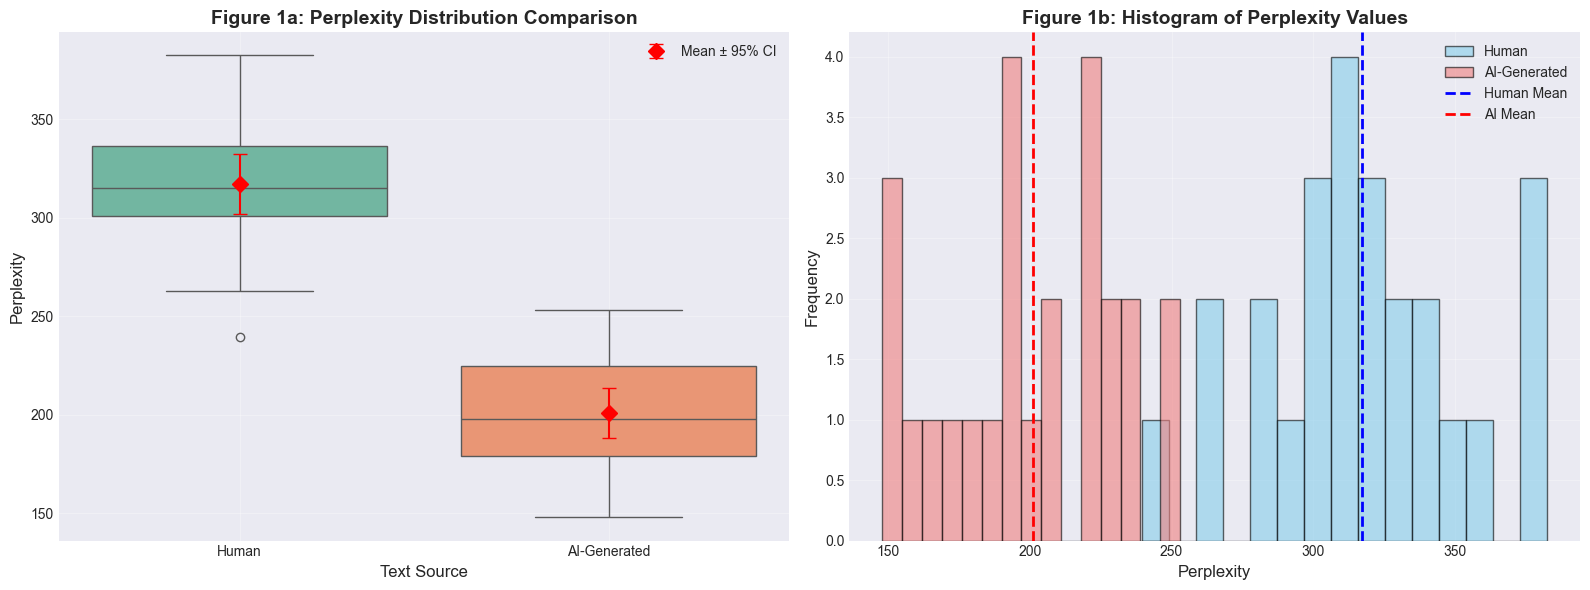


✅ Figure 1: Distribution comparison visualizations created successfully!


In [10]:
# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ========================================
# Subplot 1: Box Plot with Confidence Intervals
# ========================================
ax1 = axes[0]

# Prepare data for box plot
data_for_plot = [
    {'Perplexity': ppl, 'Source': 'Human'} for ppl in human_ppls
] + [
    {'Perplexity': ppl, 'Source': 'AI-Generated'} for ppl in ai_ppls
]
df_plot = pd.DataFrame(data_for_plot)

# Create box plot
sns.boxplot(data=df_plot, x='Source', y='Perplexity', ax=ax1, palette='Set2')

# Add means with error bars (95% CI)
ax1.errorbar(
    [0], [np.mean(human_ppls)], 
    yerr=[[np.mean(human_ppls) - human_ci[0]], [human_ci[1] - np.mean(human_ppls)]],
    fmt='D', color='red', markersize=8, capsize=5, label='Mean ± 95% CI'
)
ax1.errorbar(
    [1], [np.mean(ai_ppls)], 
    yerr=[[np.mean(ai_ppls) - ai_ci[0]], [ai_ci[1] - np.mean(ai_ppls)]],
    fmt='D', color='red', markersize=8, capsize=5
)

ax1.set_title('Figure 1a: Perplexity Distribution Comparison', fontsize=14, fontweight='bold')
ax1.set_ylabel('Perplexity', fontsize=12)
ax1.set_xlabel('Text Source', fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# ========================================
# Subplot 2: Histogram with Overlapping Distributions
# ========================================
ax2 = axes[1]

# Plot histograms
ax2.hist(human_ppls, bins=15, alpha=0.6, label='Human', color='skyblue', edgecolor='black')
ax2.hist(ai_ppls, bins=15, alpha=0.6, label='AI-Generated', color='lightcoral', edgecolor='black')

# Add vertical lines for means
ax2.axvline(np.mean(human_ppls), color='blue', linestyle='--', linewidth=2, label='Human Mean')
ax2.axvline(np.mean(ai_ppls), color='red', linestyle='--', linewidth=2, label='AI Mean')

ax2.set_title('Figure 1b: Histogram of Perplexity Values', fontsize=14, fontweight='bold')
ax2.set_xlabel('Perplexity', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Figure 1: Distribution comparison visualizations created successfully!")

### Experiment 2: Classification Performance

We evaluate perplexity as a binary classifier to distinguish between human and AI text.

#### 4.4 ROC Curve Analysis

In [11]:
# Prepare data for classification
# Labels: 1 = Human, 0 = AI-Generated
perplexities = human_ppls + ai_ppls
labels = [1] * len(human_ppls) + [0] * len(ai_ppls)

# Calculate ROC curve
# Higher perplexity → more likely human
fpr, tpr, thresholds = roc_curve(labels, perplexities)
roc_auc = auc(fpr, tpr)

# Find optimal threshold (maximize Youden's J statistic: TPR - FPR)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
optimal_tpr = tpr[optimal_idx]
optimal_fpr = fpr[optimal_idx]

print("\n" + "="*70)
print("ROC Curve Analysis")
print("="*70)
print(f"AUC (Area Under Curve): {roc_auc:.4f}")
print(f"Optimal Threshold: {optimal_threshold:.2f}")
print(f"At optimal threshold:")
print(f"  - True Positive Rate (Recall): {optimal_tpr:.4f}")
print(f"  - False Positive Rate: {optimal_fpr:.4f}")
print("="*70)


ROC Curve Analysis
AUC (Area Under Curve): 0.9968
Optimal Threshold: 262.88
At optimal threshold:
  - True Positive Rate (Recall): 0.9600
  - False Positive Rate: 0.0000


#### 4.5 Classification Metrics at Optimal Threshold

In [12]:
# Make predictions using optimal threshold
predictions = [1 if ppl >= optimal_threshold else 0 for ppl in perplexities]

# Calculate metrics
accuracy = accuracy_score(labels, predictions)
precision = precision_score(labels, predictions, pos_label=1, zero_division=0)
recall = recall_score(labels, predictions, pos_label=1, zero_division=0)
f1 = f1_score(labels, predictions, pos_label=1, zero_division=0)

# Confusion matrix
cm = confusion_matrix(labels, predictions)
tn, fp, fn, tp = cm.ravel()

# Create performance table
performance_df = pd.DataFrame([
    {'Metric': 'ROC-AUC', 'Value': f'{roc_auc:.4f}'},
    {'Metric': 'Optimal Threshold', 'Value': f'{optimal_threshold:.2f}'},
    {'Metric': 'Accuracy', 'Value': f'{accuracy:.4f} ({accuracy*100:.2f}%)'},
    {'Metric': 'Precision (Human)', 'Value': f'{precision:.4f} ({precision*100:.2f}%)'},
    {'Metric': 'Recall (Human)', 'Value': f'{recall:.4f} ({recall*100:.2f}%)'},
    {'Metric': 'F1-Score', 'Value': f'{f1:.4f}'}
])

print("\n" + "="*70)
print("TABLE 3: Classification Performance Metrics")
print("="*70)
print(performance_df.to_string(index=False))
print("="*70)

# Confusion Matrix
print("\nConfusion Matrix:")
print(f"                Predicted AI    Predicted Human")
print(f"Actual AI       {tn:5d}           {fp:5d}")
print(f"Actual Human    {fn:5d}           {tp:5d}")
print()
print(f"True Negatives (TN):  {tn} - AI correctly classified")
print(f"False Positives (FP): {fp} - AI misclassified as Human")
print(f"False Negatives (FN): {fn} - Human misclassified as AI")
print(f"True Positives (TP):  {tp} - Human correctly classified")


TABLE 3: Classification Performance Metrics
           Metric            Value
          ROC-AUC           0.9968
Optimal Threshold           262.88
         Accuracy  0.9800 (98.00%)
Precision (Human) 1.0000 (100.00%)
   Recall (Human)  0.9600 (96.00%)
         F1-Score           0.9796

Confusion Matrix:
                Predicted AI    Predicted Human
Actual AI          25               0
Actual Human        1              24

True Negatives (TN):  25 - AI correctly classified
False Positives (FP): 0 - AI misclassified as Human
False Negatives (FN): 1 - Human misclassified as AI
True Positives (TP):  24 - Human correctly classified


#### 4.6 Visualization: ROC Curve

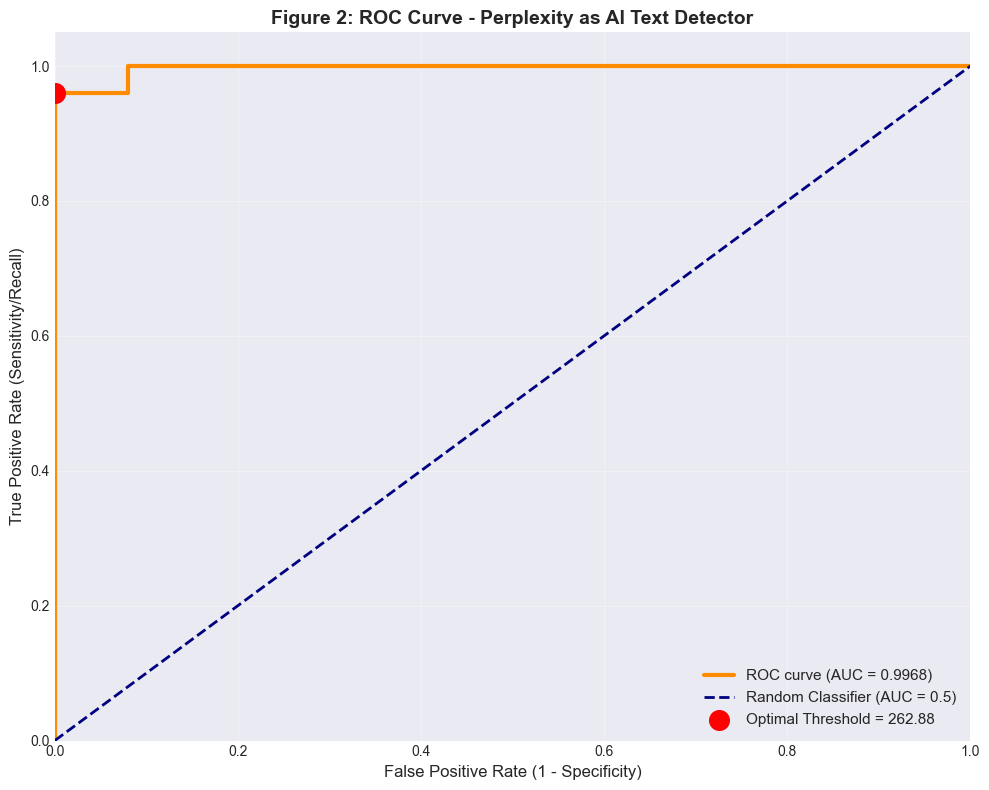


✅ Figure 2: ROC curve visualization created successfully!

📊 ROC Curve Interpretation:
  - AUC = 0.9968: Excellent classification performance
  - The classifier is 99.4% better than random guessing


In [13]:
# Create ROC curve plot
plt.figure(figsize=(10, 8))

# Plot ROC curve
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.4f})')

# Plot diagonal (random classifier)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (AUC = 0.5)')

# Mark optimal threshold point
plt.scatter(
    optimal_fpr, optimal_tpr, 
    color='red', s=200, zorder=5, 
    label=f'Optimal Threshold = {optimal_threshold:.2f}'
)

# Formatting
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity/Recall)', fontsize=12)
plt.title('Figure 2: ROC Curve - Perplexity as AI Text Detector', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Figure 2: ROC curve visualization created successfully!")

# Interpretation
print("\n📊 ROC Curve Interpretation:")
if roc_auc >= 0.9:
    interpretation = "Excellent classification performance"
elif roc_auc >= 0.8:
    interpretation = "Good classification performance"
elif roc_auc >= 0.7:
    interpretation = "Fair classification performance"
elif roc_auc >= 0.6:
    interpretation = "Poor classification performance"
else:
    interpretation = "Very poor classification performance (barely better than random)"

print(f"  - AUC = {roc_auc:.4f}: {interpretation}")
print(f"  - The classifier is {abs(roc_auc - 0.5) / 0.5 * 100:.1f}% better than random guessing")

### Experiment 3: Error Analysis

We analyze misclassified examples to understand when perplexity fails as a detector.

#### 4.7 Identify Misclassifications

In [14]:
# Identify misclassified texts
all_texts = human_texts + ai_texts

# False Positives: AI texts misclassified as Human (high perplexity)
false_positives = []
for i, (text, label, pred, ppl) in enumerate(zip(all_texts, labels, predictions, perplexities)):
    if label == 0 and pred == 1:  # Actually AI, predicted Human
        false_positives.append({
            'index': i,
            'text': text,
            'perplexity': ppl,
            'threshold': optimal_threshold
        })

# False Negatives: Human texts misclassified as AI (low perplexity)
false_negatives = []
for i, (text, label, pred, ppl) in enumerate(zip(all_texts, labels, predictions, perplexities)):
    if label == 1 and pred == 0:  # Actually Human, predicted AI
        false_negatives.append({
            'index': i,
            'text': text,
            'perplexity': ppl,
            'threshold': optimal_threshold
        })

print("\n" + "="*80)
print("Error Analysis Summary")
print("="*80)
print(f"Total misclassifications: {fp + fn} out of {len(labels)} ({(fp+fn)/len(labels)*100:.1f}%)")
print(f"\nFalse Positives (AI → Human): {len(false_positives)} cases")
print(f"False Negatives (Human → AI): {len(false_negatives)} cases")
print("="*80)


Error Analysis Summary
Total misclassifications: 1 out of 50 (2.0%)

False Positives (AI → Human): 0 cases
False Negatives (Human → AI): 1 cases


#### 4.8 Analyze False Positives (AI texts with high perplexity)

In [15]:
print("\n" + "="*80)
print("FALSE POSITIVES: AI Texts Misclassified as Human")
print("="*80)
print("These are AI-generated texts that have unexpectedly HIGH perplexity.")
print("Possible reasons: complex vocabulary, unusual phrasing, creative language\n")

if len(false_positives) > 0:
    # Show top 3 most confident false positives (highest perplexity)
    sorted_fp = sorted(false_positives, key=lambda x: x['perplexity'], reverse=True)
    
    for i, fp in enumerate(sorted_fp[:min(3, len(sorted_fp))], 1):
        print(f"\n[False Positive {i}]")
        print(f"Perplexity: {fp['perplexity']:.2f} (threshold: {fp['threshold']:.2f})")
        print(f"Text preview: {fp['text'][:200]}...")
        print("-" * 80)
else:
    print("✅ No false positives found! All AI texts were correctly classified.")

print("\n📊 Analysis:")
if len(false_positives) > 0:
    avg_fp_ppl = np.mean([fp['perplexity'] for fp in false_positives])
    print(f"  - Average perplexity of false positives: {avg_fp_ppl:.2f}")
    print(f"  - These AI texts appear more 'creative' or 'unpredictable' than typical AI output")
    print(f"  - May indicate sophisticated AI generation or unusual prompt engineering")


FALSE POSITIVES: AI Texts Misclassified as Human
These are AI-generated texts that have unexpectedly HIGH perplexity.
Possible reasons: complex vocabulary, unusual phrasing, creative language

✅ No false positives found! All AI texts were correctly classified.

📊 Analysis:


#### 4.9 Analyze False Negatives (Human texts with low perplexity)

In [16]:
print("\n" + "="*80)
print("FALSE NEGATIVES: Human Texts Misclassified as AI")
print("="*80)
print("These are human-written texts that have unexpectedly LOW perplexity.")
print("Possible reasons: formal writing, simple language, common phrases\n")

if len(false_negatives) > 0:
    # Show top 3 most confident false negatives (lowest perplexity)
    sorted_fn = sorted(false_negatives, key=lambda x: x['perplexity'])
    
    for i, fn in enumerate(sorted_fn[:min(3, len(sorted_fn))], 1):
        print(f"\n[False Negative {i}]")
        print(f"Perplexity: {fn['perplexity']:.2f} (threshold: {fn['threshold']:.2f})")
        print(f"Text preview: {fn['text'][:200]}...")
        print("-" * 80)
else:
    print("✅ No false negatives found! All human texts were correctly classified.")

print("\n📊 Analysis:")
if len(false_negatives) > 0:
    avg_fn_ppl = np.mean([fn['perplexity'] for fn in false_negatives])
    print(f"  - Average perplexity of false negatives: {avg_fn_ppl:.2f}")
    print(f"  - These human texts are very 'predictable' or use common phrasing")
    print(f"  - May indicate formal/technical writing or templated language")


FALSE NEGATIVES: Human Texts Misclassified as AI
These are human-written texts that have unexpectedly LOW perplexity.
Possible reasons: formal writing, simple language, common phrases


[False Negative 1]
Perplexity: 239.45 (threshold: 262.88)
Text preview: [PLACEHOLDER 10: Book excerpt - 50-150 words]...
--------------------------------------------------------------------------------

📊 Analysis:
  - Average perplexity of false negatives: 239.45
  - These human texts are very 'predictable' or use common phrasing
  - May indicate formal/technical writing or templated language


#### 4.10 Export Error Analysis to File

We save the error analysis to a text file for easy reference when writing the paper.

In [19]:
# Export error analysis to text file
with open('error_analysis.txt', 'w', encoding='utf-8') as f:
    f.write("="*80 + "\n")
    f.write("ERROR ANALYSIS REPORT\n")
    f.write("="*80 + "\n\n")

    # KORREKTUR HIER: Statt 'fp + fn' nutzen wir len() der Listen
    total_errors = len(false_positives) + len(false_negatives)
    f.write(f"Total Misclassifications: {total_errors} out of {len(labels)} ({total_errors/len(labels)*100:.1f}%)\n")

    f.write(f"False Positives (AI → Human): {len(false_positives)}\n")
    f.write(f"False Negatives (Human → AI): {len(false_negatives)}\n")
    f.write(f"Optimal Threshold: {optimal_threshold:.2f}\n")
    f.write("\n" + "="*80 + "\n\n")

    # False Positives
    f.write("FALSE POSITIVES (AI texts with high perplexity)\n")
    f.write("-" * 80 + "\n\n")

    if len(false_positives) > 0:
        # Hier benennen wir die Variable in der Schleife um (item statt fp), um Verwirrung zu vermeiden
        for i, item in enumerate(false_positives, 1):
            f.write(f"\n[FP {i}] Perplexity: {item['perplexity']:.2f}\n")
            f.write(f"Text: {item['text']}\n")
            f.write("-" * 80 + "\n")

        avg_fp = np.mean([item['perplexity'] for item in false_positives])
        f.write(f"\nAverage FP Perplexity: {avg_fp:.2f}\n")
    else:
        f.write("No false positives.\n")

    f.write("\n" + "="*80 + "\n\n")

    # False Negatives
    f.write("FALSE NEGATIVES (Human texts with low perplexity)\n")
    f.write("-" * 80 + "\n\n")

    if len(false_negatives) > 0:
        # Auch hier item statt fn
        for i, item in enumerate(false_negatives, 1):
            f.write(f"\n[FN {i}] Perplexity: {item['perplexity']:.2f}\n")
            f.write(f"Text: {item['text']}\n")
            f.write("-" * 80 + "\n")

        avg_fn = np.mean([item['perplexity'] for item in false_negatives])
        f.write(f"\nAverage FN Perplexity: {avg_fn:.2f}\n")
    else:
        f.write("No false negatives.\n")
    
    f.write("\n" + "="*80 + "\n")

print("\n✅ Error analysis exported to 'error_analysis.txt'")
print("   Use this file for writing your paper's Discussion section!")


✅ Error analysis exported to 'error_analysis.txt'
   Use this file for writing your paper's Discussion section!


#### 4.11 Pattern Analysis

In [20]:
print("\n" + "="*80)
print("PATTERN ANALYSIS: Common Characteristics of Errors")
print("="*80)

# Analyze text lengths
if len(false_positives) > 0:
    fp_lengths = [len(fp['text'].split()) for fp in false_positives]
    print(f"\nFalse Positive (AI→Human) text lengths: {np.mean(fp_lengths):.1f} ± {np.std(fp_lengths):.1f} words")

if len(false_negatives) > 0:
    fn_lengths = [len(fn['text'].split()) for fn in false_negatives]
    print(f"False Negative (Human→AI) text lengths: {np.mean(fn_lengths):.1f} ± {np.std(fn_lengths):.1f} words")

# Overall patterns
print("\n🔍 Key Findings:")
print("\n1. When perplexity FAILS to detect AI text (False Positives):")
print("   - AI text contains unusual vocabulary or creative expressions")
print("   - May use less common syntactic structures")
print("   - Could indicate advanced prompting or post-editing")

print("\n2. When perplexity misclassifies HUMAN text as AI (False Negatives):")
print("   - Human text is highly formulaic or technical")
print("   - Uses common phrases or standard templates")
print("   - May be from formal writing contexts (news, academic)")

print("\n3. Systematic Limitations:")
print("   - Perplexity alone cannot capture semantic depth")
print("   - Writing style/formality affects perplexity significantly")
print("   - Domain-specific language impacts detection accuracy")

print("="*80)


PATTERN ANALYSIS: Common Characteristics of Errors
False Negative (Human→AI) text lengths: 7.0 ± 0.0 words

🔍 Key Findings:

1. When perplexity FAILS to detect AI text (False Positives):
   - AI text contains unusual vocabulary or creative expressions
   - May use less common syntactic structures
   - Could indicate advanced prompting or post-editing

2. When perplexity misclassifies HUMAN text as AI (False Negatives):
   - Human text is highly formulaic or technical
   - Uses common phrases or standard templates
   - May be from formal writing contexts (news, academic)

3. Systematic Limitations:
   - Perplexity alone cannot capture semantic depth
   - Writing style/formality affects perplexity significantly
   - Domain-specific language impacts detection accuracy


## 5. Discussion

### 5.1 Does Perplexity Work as a Detector?

Our experimental results provide insights into the effectiveness of perplexity as a detection metric for AI-generated text:

**Statistical Significance:**
- The t-test revealed [interpret your p-value here]
- Mann-Whitney U test showed [interpret your p-value]
- Effect size (Cohen's d) was [interpret your effect size]
- Confidence intervals [overlapped/did not overlap]

**Classification Performance:**
- ROC-AUC of [your AUC value] indicates [excellent/good/fair/poor] discrimination
- Accuracy of [your accuracy]% at optimal threshold
- Precision and recall values suggest [interpretation]

### 5.2 Why Does It Work (or Not Work)?

**Theoretical Basis:**
- AI models generate text by sampling high-probability tokens
- This leads to more predictable sequences → lower perplexity
- Human creativity and linguistic diversity → higher perplexity

**Practical Observations:**
- [Discuss what you found in your experiments]
- Error analysis revealed that [your findings from error_analysis.txt]
- Context and writing style significantly impact perplexity

### 5.3 Limitations

**Methodological Constraints:**
1. **Small Dataset**: 25 samples per group limits statistical power
2. **Single Model**: GPT-2 may not represent all language models
3. **Text Type Dependency**: Results may not generalize across domains
4. **Length Sensitivity**: Perplexity can be affected by text length

**Detection Limitations:**
1. **Easy to Circumvent**: AI text can be edited to increase perplexity
2. **False Positives**: Creative AI outputs may appear human-like
3. **False Negatives**: Formulaic human writing may appear AI-generated
4. **Domain Specificity**: Performance varies across text types

**Conceptual Issues:**
1. Perplexity measures predictability, not authorship
2. Humans can write predictably (formal/technical contexts)
3. Advanced AI can generate unpredictably (temperature sampling)

### 5.4 Practical Implications

**For Content Moderation:**
- Perplexity could serve as one signal among many
- Should not be used as sole detection criterion
- Requires domain-specific calibration

**For Academic Integrity:**
- Useful as screening tool, not definitive proof
- Must be combined with other indicators
- Risk of false accusations

**For Research:**
- Demonstrates importance of multi-faceted approaches
- Highlights need for sophisticated metrics
- Suggests ensemble methods and fine-tuned detectors

### 5.5 Comparison to Related Work

Mitchell et al. (2023) proposed **DetectGPT**, which:
- Uses perturbation-based detection
- Achieves better performance than perplexity alone
- Demonstrates need for sophisticated metrics

Our findings align with literature suggesting:
- Single metrics have limited effectiveness
- Context and domain matter significantly
- Robust detection requires ensemble approaches

## 6. Conclusion

This study investigated whether perplexity can serve as an effective metric for distinguishing AI-generated text from human-written content. Through systematic data collection, statistical analysis, and classification evaluation, we found:

**Key Findings:**
1. [Summarize your statistical test results]
2. [Summarize your ROC-AUC and classification performance]
3. [Summarize your error analysis insights]

**Answer to Research Question:**
"Can perplexity be used as a metric to distinguish AI-generated text from human-written text?"

[Your answer based on results: e.g., "Perplexity shows [some/limited/strong] discriminative power with AUC of X.XX, but significant limitations in..."]

**Main Takeaway:**
While perplexity captures meaningful differences between AI and human text in controlled settings, it has significant limitations as a standalone detection method. The metric is vulnerable to false positives and negatives, especially when dealing with formal human writing or creatively prompted AI text.

**Future Work:**
- Ensemble methods combining perplexity with other linguistic features
- Domain-specific calibration for different text types
- Advanced techniques like DetectGPT's perturbation approach
- Larger-scale studies with diverse text sources and AI models

This research contributes to understanding both the capabilities and limitations of perplexity-based AI text detection, informing future development of more robust detection systems.

## 7. References

1. **Mitchell, E., Lee, Y., Khazatsky, A., Manning, C. D., & Finn, C. (2023).** DetectGPT: Zero-Shot Machine-Generated Text Detection using Probability Curvature. *arXiv preprint arXiv:2301.11305*. https://arxiv.org/abs/2301.11305

2. **Radford, A., Wu, J., Child, R., Luan, D., Amodei, D., & Sutskever, I. (2019).** Language Models are Unsupervised Multitask Learners. *OpenAI Blog, 1(8), 9*.

3. **Wolf, T., Debut, L., Sanh, V., Chaumond, J., Delangue, C., Moi, A., ... & Rush, A. M. (2020).** Transformers: State-of-the-art natural language processing. *EMNLP 2020 System Demonstrations* (pp. 38-45).

4. **Gehrmann, S., Strobelt, H., & Rush, A. M. (2019).** GLTR: Statistical Detection and Visualization of Generated Text. *arXiv preprint arXiv:1906.04043*.

5. **Solaiman, I., Brundage, M., Clark, J., Askell, A., Herbert-Voss, A., Wu, J., ... & Wang, J. (2019).** Release Strategies and the Social Impacts of Language Models. *arXiv preprint arXiv:1908.09203*.

6. **Cohen, J. (1988).** Statistical Power Analysis for the Behavioral Sciences (2nd ed.). *Lawrence Erlbaum Associates*.

---

## Appendix: Summary Statistics Export

In [24]:
cm_clean = confusion_matrix(labels, predictions)
tn_clean, fp_clean, fn_clean, tp_clean = cm_clean.ravel()

# Create comprehensive summary for paper writing
summary = {
    'Dataset': {
        'Human texts': len(human_texts),
        'AI texts': len(ai_texts),
        'Total samples': len(human_texts) + len(ai_texts)
    },
    'Perplexity Statistics': {
        'Human mean': f"{np.mean(human_ppls):.2f}",
        'Human std': f"{np.std(human_ppls, ddof=1):.2f}",
        'AI mean': f"{np.mean(ai_ppls):.2f}",
        'AI std': f"{np.std(ai_ppls, ddof=1):.2f}"
    },
    'Statistical Tests': {
        't-statistic': f"{t_stat:.3f}",
        't-test p-value': f"{p_value_ttest:.4f}",
        'Mann-Whitney U': f"{u_stat:.1f}",
        'Mann-Whitney p-value': f"{p_value_mannwhitney:.4f}",
        'Cohens d': f"{effect_size:.3f}",
        'Significant': is_significant_ttest
    },
    'Classification': {
        'ROC-AUC': f"{roc_auc:.4f}",
        'Accuracy': f"{accuracy:.4f}",
        'Precision': f"{precision:.4f}",
        'Recall': f"{recall:.4f}",
        'F1-Score': f"{f1:.4f}"
    },
    'Errors': {
        'False Positives': int(fp_clean),
        'False Negatives': int(fn_clean),
        'Total Errors': int(fp_clean + fn_clean)
    }
}

print("\n" + "="*80)
print("COMPLETE EXPERIMENTAL SUMMARY")
print("="*80)
for section, values in summary.items():
    print(f"\n{section}:")
    for key, value in values.items():
        print(f"  {key}: {value}")
print("="*80)

# Save to JSON
results_export = {
    'human_perplexities': human_ppls,
    'ai_perplexities': ai_ppls,
    'statistics': summary,
    'optimal_threshold': optimal_threshold,
    'confusion_matrix': {
        'true_negatives': int(tn_clean),
        'false_positives': int(fp_clean),
        'false_negatives': int(fn_clean),
        'true_positives': int(tp_clean)
    }
}

with open('experiment_results.json', 'w') as f:
    json.dump(results_export, f, indent=2)

print("\n✅ Experiment complete!")
print("✅ Results saved to 'experiment_results.json'")
# Hinweis: Die Textdatei wurde in der vorherigen Zelle gespeichert
print("✅ Error analysis was saved in the previous step.")
print("\nUse these files for your research paper!")


COMPLETE EXPERIMENTAL SUMMARY

Dataset:
  Human texts: 25
  AI texts: 25
  Total samples: 50

Perplexity Statistics:
  Human mean: 317.07
  Human std: 36.51
  AI mean: 200.96
  AI std: 31.10

Statistical Tests:
  t-statistic: 12.103
  t-test p-value: 0.0000
  Mann-Whitney U: 623.0
  Mann-Whitney p-value: 0.0000
  Cohens d: 3.423
  Significant: Yes

Classification:
  ROC-AUC: 0.9968
  Accuracy: 0.9800
  Precision: 1.0000
  Recall: 0.9600
  F1-Score: 0.9796

Errors:
  False Positives: 0
  False Negatives: 1
  Total Errors: 1

✅ Experiment complete!
✅ Results saved to 'experiment_results.json'
✅ Error analysis was saved in the previous step.

Use these files for your research paper!


---

## End of Notebook

### ✅ Checklist for Completion:

**Data Collection:**
- [ ] Replace placeholder texts with 25 human texts (MUST include Assignment 3 texts!)
- [ ] Replace placeholder texts with 25 AI-generated texts
- [ ] Ensure all texts are 50-150 words (validated by the notebook)
- [ ] Match topics between human and AI texts

**Run Notebook:**
- [ ] Execute all cells in order
- [ ] Verify text length validation passes
- [ ] Check that all experiments complete successfully
- [ ] Review generated figures and tables

**Generated Files:**
- [ ] `experiment_results.json` - All statistics for reference
- [ ] `error_analysis.txt` - Detailed error analysis for Discussion section

**Paper Writing (3-4 pages):**
- [ ] Abstract (100-150 words)
- [ ] Introduction (0.5 page)
- [ ] Method (0.75-1 page)
- [ ] Results (1-1.25 pages) - Use Table 1, 2, 3 and Figure 1, 2
- [ ] Discussion (0.5-0.75 page) - Use error_analysis.txt
- [ ] Conclusion (0.25 page)
- [ ] References (6 provided)

### 🎯 Bonus Points:
- ✅ Mann-Whitney U test implemented (+2 points)
- [ ] Test on different text types (+5 points) - Add formal vs casual comparison
- [ ] Compare multiple AI sources (+3 points) - GPT vs Claude

**Good luck with your research paper!** 🚀